**Customer Churn Analysis**
Understanding customer behavior and predicting churn through data analysis.

*Project Overview*
This project analyzes customer churn data to identify patterns and key factors responsible for customer attrition. The insights derived from this analysis can help businesses improve customer retention strategies, reduce customer loss, and enhance long-term profitability.

*Objectives*
Understand customer behavior and usage patterns
Identify the major factors influencing customer churn
Perform data cleaning and preprocessing
Conduct exploratory data analysis (EDA)
Generate actionable business insights
Build a foundation for churn prediction modeling


*Workflow*
Data Loading
Import the dataset and examine its structure.
Data Cleaning
Handle missing values, duplicates, and incorrect data types.
Exploratory Data Analysis
Analyze customer demographics, balances, products, and churn trends.
Feature Engineering
Prepare variables for deeper analysis and predictive modeling.
Insights and Conclusion
Summarize findings and provide business recommendations.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
df = pd.read_csv('Bank Customer Churn Prediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


** BASIC ANALYSIS **


In [2]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [3]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [4]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [5]:
df.dtypes

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

In [6]:
df['country'].unique()       

array(['France', 'Spain', 'Germany'], dtype=object)

In [7]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')

In [8]:
from sqlalchemy import create_engine

imporyin datya to sql dfoe furtherb 

In [9]:
host = "localhost"
port = 3306
username = "root"
password = "anujanuj"
database = "bank"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

# Upload cleaned dataframe to MySQL
df.to_sql(
    name="bank_churn",      # table name in MySQL
    con=engine,
    if_exists="replace",     # replace / append
    index=False
)

print("Cleaned Python data imported successfully!")

Cleaned Python data imported successfully!


**Overall Churn Rate Analysis**
We calculate the churn rate to determine the percentage of customers who have exited the company.

In [10]:
churn_rate = df['churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 20.37%


Average Age by Churn Status
We calculate the average age of customers grouped by churn status to understand if age influences customer exit behavior.

In [11]:
df.groupby('churn')["age"].mean()

churn
0    37.408389
1    44.837997
Name: age, dtype: float64

In [12]:
df.groupby("products_number")["churn"].mean()

products_number
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: churn, dtype: float64

*Using a pivot table to see if salary differences drive churn differently in each country*


In [13]:
salary_analysis = df.pivot_table(index='country', columns='churn', values='estimated_salary', aggfunc='mean')
print(salary_analysis)

churn                0              1
country                              
France    99217.097331  103439.278296
Germany  102414.657876   98403.886450
Spain     98602.369864  103629.554818


**Outlier Detection and Visualization**
We identify and visualize outliers in numerical features using boxplots and the IQR method to understand data distribution and potential anomalies.

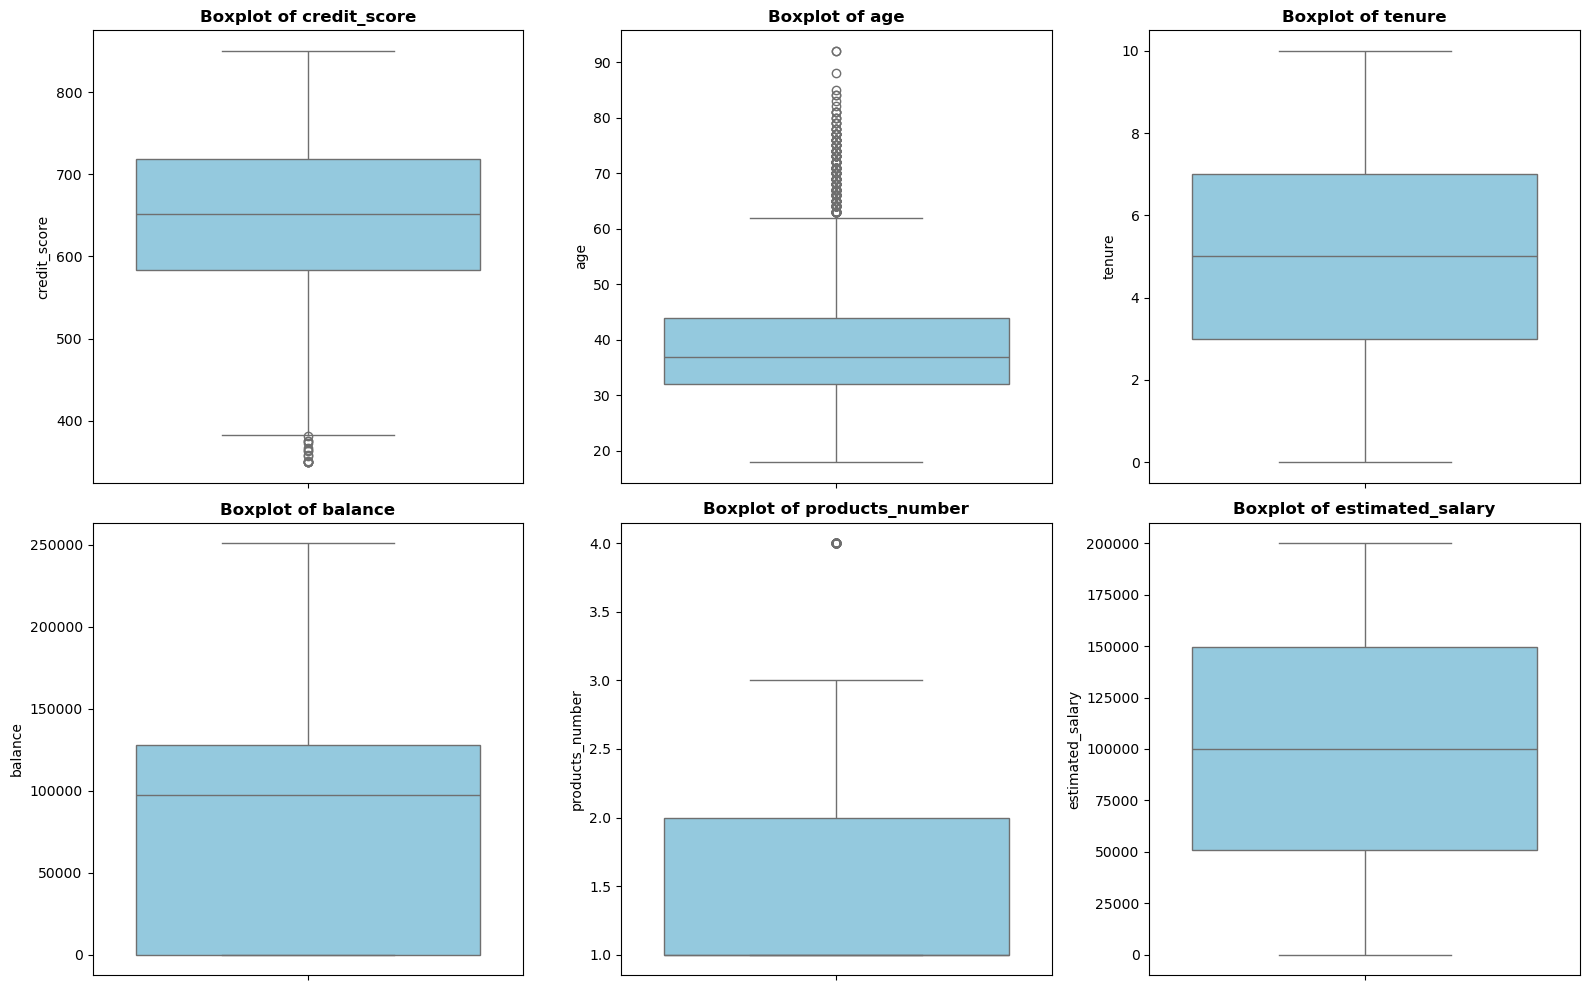

Outlier Detection Report
credit_score: 15 outliers found
age: 359 outliers found
tenure: 0 outliers found
balance: 0 outliers found
products_number: 60 outliers found
estimated_salary: 0 outliers found


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
num_cols = [
    'credit_score',
    'age',
    'tenure',
    'balance',
    'products_number',
    'estimated_salary'
]

# Boxplots
plt.figure(figsize=(16,10))

for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

# Outlier Report
print("Outlier Detection Report")

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers found")

**Relationship Between Features and Churn**
We analyze how categorical and numerical variables relate to customer churn using count plots and distribution plots to identify key patterns.

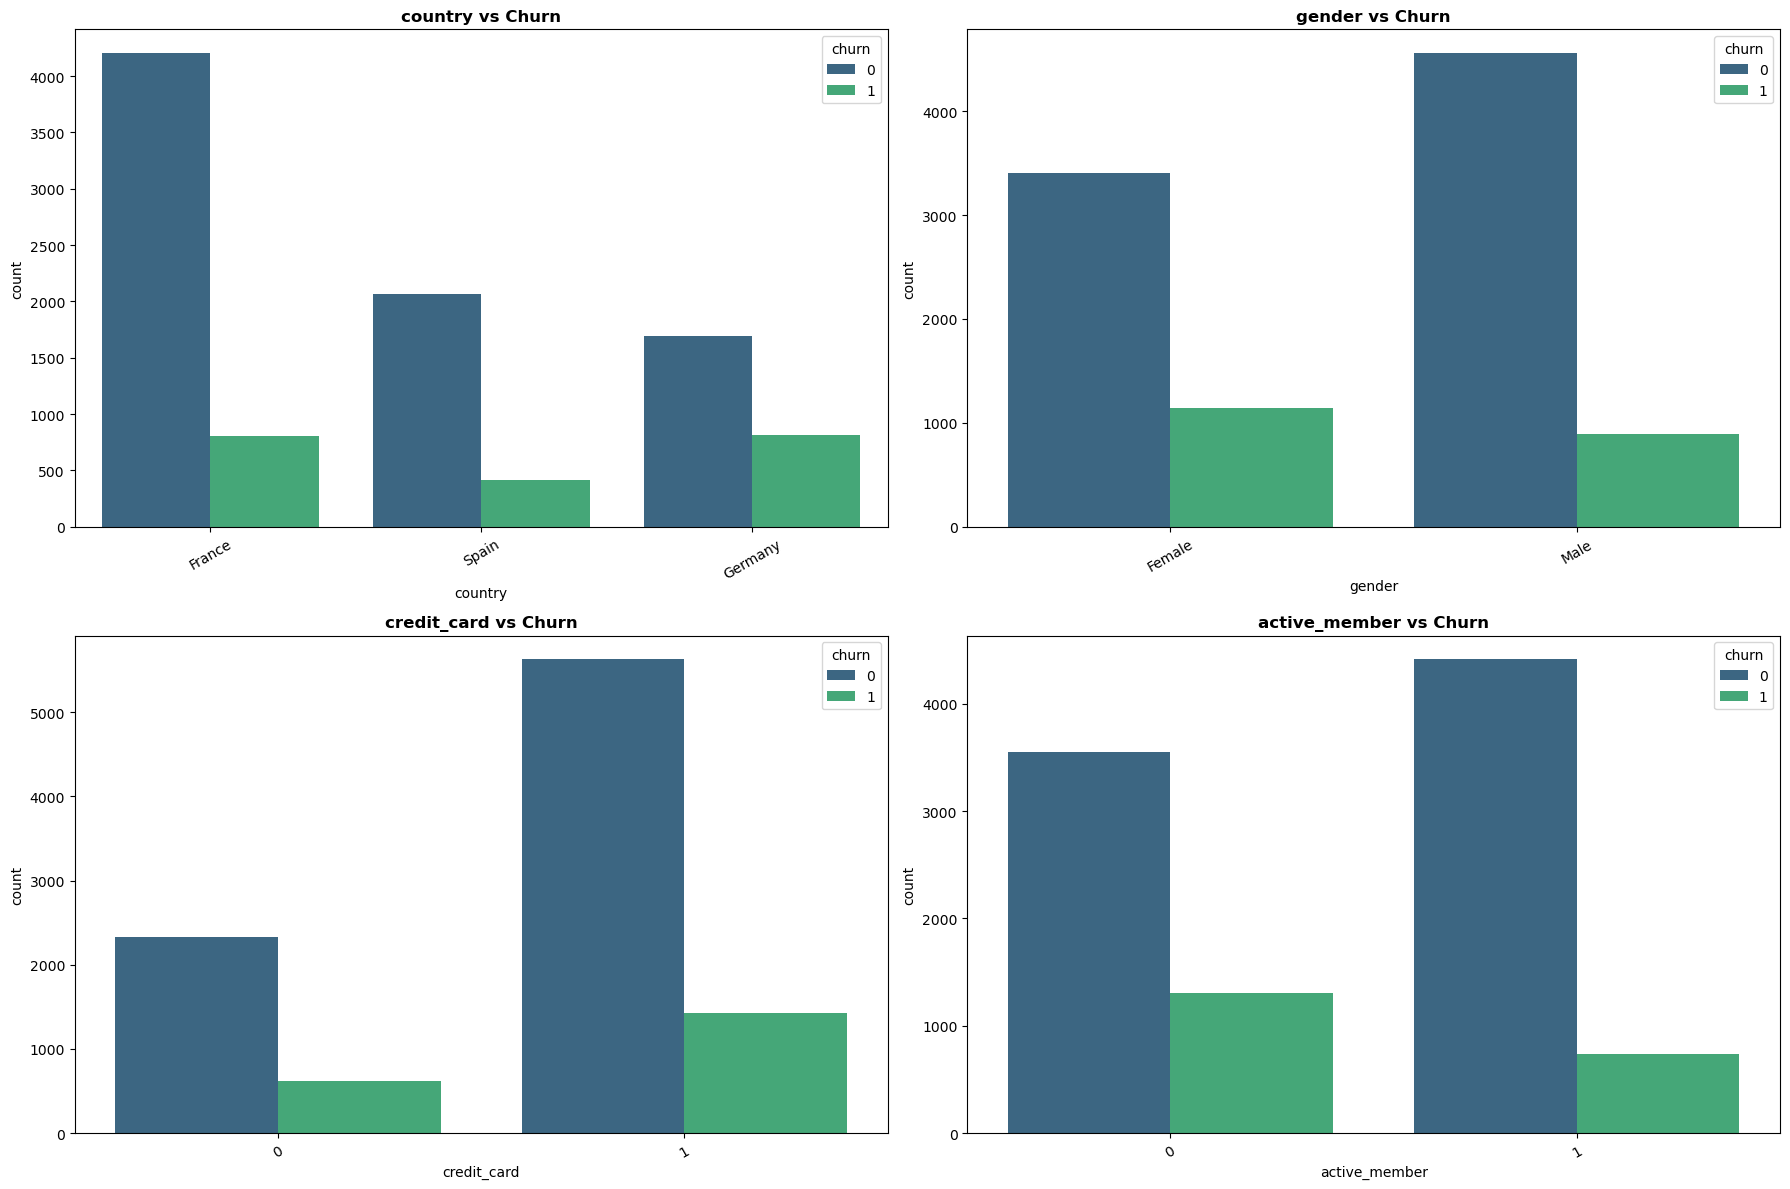

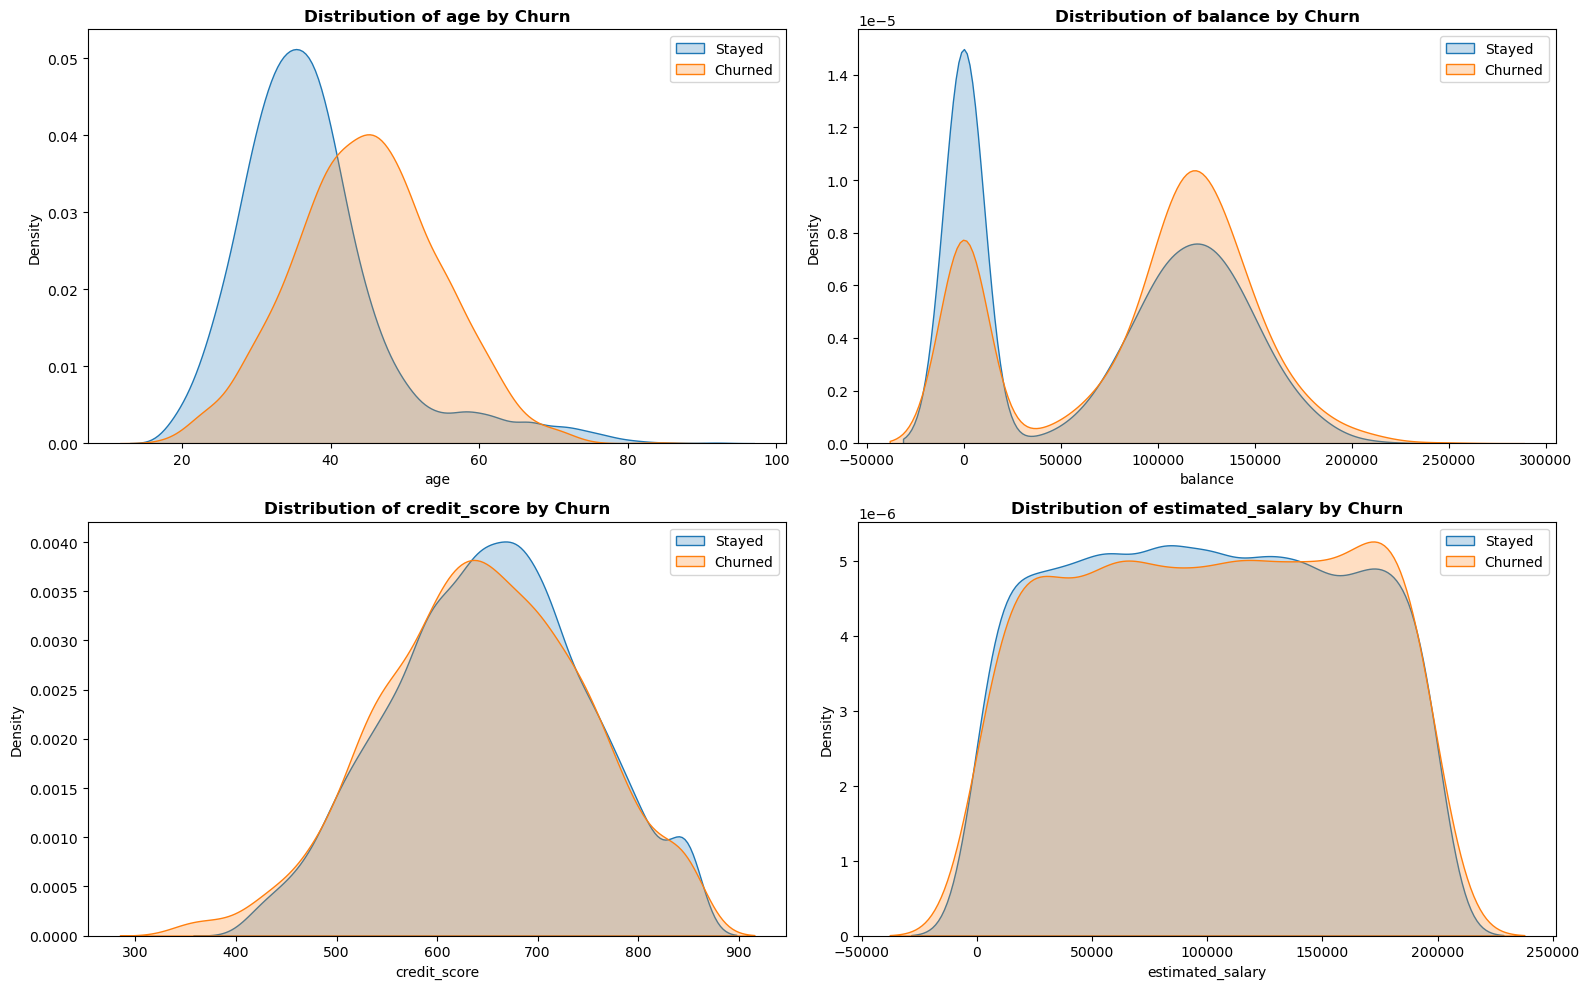

In [15]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Relationship between Categorical Variables and Churn
# -------------------------------

# Correct column names for your dataset
cat_cols = ['country', 'gender', 'credit_card', 'active_member']

plt.figure(figsize=(18,12))

for i, col in enumerate(cat_cols):
    plt.subplot(2,2,i+1)
    sns.countplot(x=col, hue='churn', data=df, palette='viridis')
    plt.title(f'{col} vs Churn', fontweight='bold')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# -------------------------------
# Relationship between Numerical Variables and Churn
# -------------------------------

num_cols = ['age', 'balance', 'credit_score', 'estimated_salary']

plt.figure(figsize=(16,10))

for i, col in enumerate(num_cols):
    plt.subplot(2,2,i+1)

    sns.kdeplot(
        data=df[df['churn']==0],
        x=col,
        label='Stayed',
        fill=True
    )

    sns.kdeplot(
        data=df[df['churn']==1],
        x=col,
        label='Churned',
        fill=True
    )

    plt.title(f'Distribution of {col} by Churn', fontweight='bold')
    plt.legend()

plt.tight_layout()
plt.show()

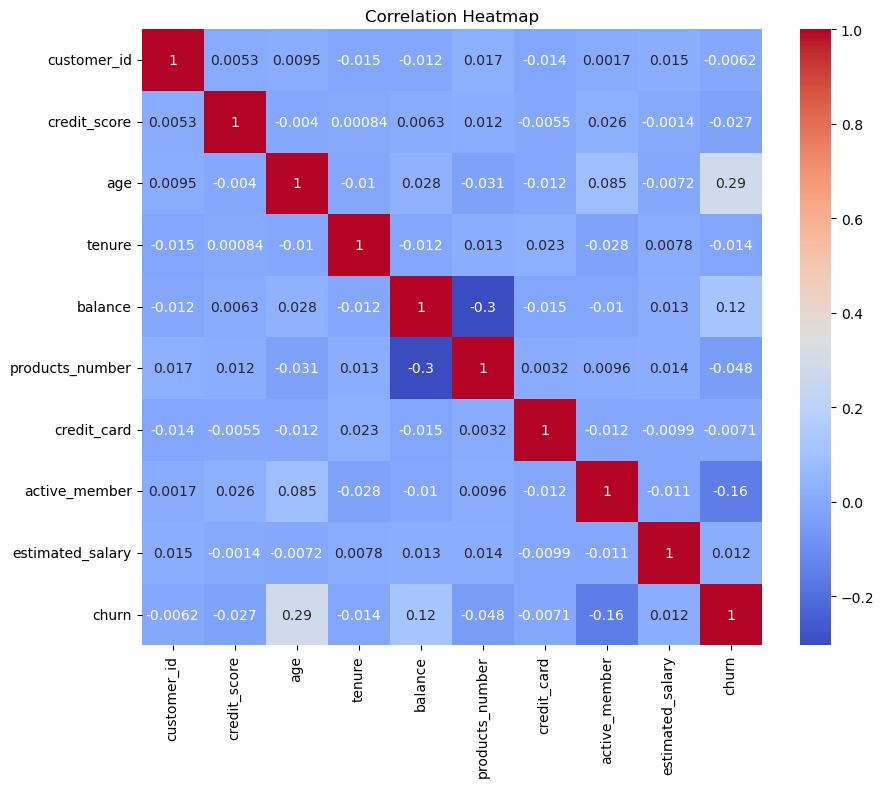

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
df_ml = pd.get_dummies(df.drop(['customer_id'], axis=1), columns=['country', 'gender'], drop_first=True)

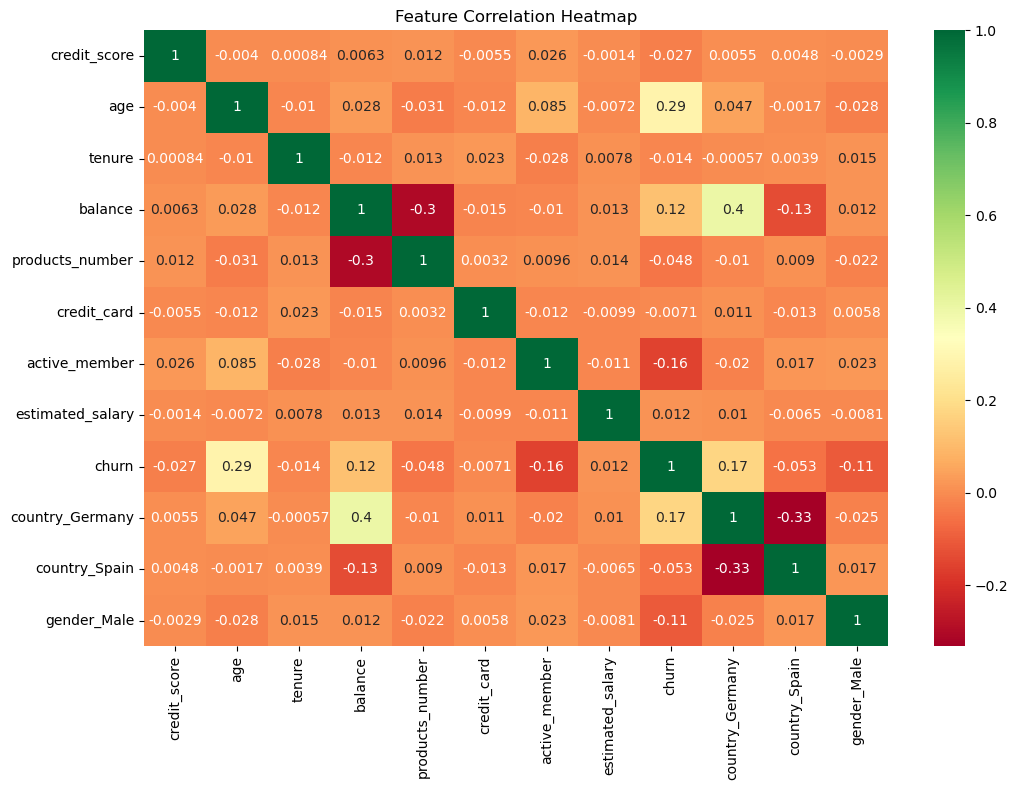

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_ml.corr(), annot=True, cmap='RdYlGn')
plt.title('Feature Correlation Heatmap')
plt.show()

In [19]:
X = df_ml.drop('churn', axis=1)
y = df_ml['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
df['churn_probability'] = rf.predict_proba(X)[:, 1]
df['predicted_churn'] = rf.predict(X)
df.to_csv('bank_churn_with_predictions.csv', index=False)

print("Model Training Complete. File 'bank_churn_with_predictions.csv' is ready for Power BI.")

Model Training Complete. File 'bank_churn_with_predictions.csv' is ready for Power BI.
